# Text Classification:

## Data
<pre>
1. we have total of 20 types of documents(Text files) and total 18828 documents(text files).
2. You can download data from this <a href='https://drive.google.com/open?id=1rxD15nyeIPIAZ-J2VYPrDRZI66-TBWvM'>link</a>, in that you will get documents.rar folder. <br>If you unzip that, you will get total of 18828 documnets. document name is defined as'ClassLabel_DocumentNumberInThatLabel'. 
so from document name, you can extract the label for that document.
4. Now our problem is to classify all the documents into any one of the class.
5. Below we provided count plot of all the labels in our data. 
</pre>

In [8]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# !pip install pyunpack
# !pip install patool
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('punkt')
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import MaxPooling1D,Conv1D,Flatten,Concatenate,Dropout,Dense,Input
from tensorflow.keras import layers,Model
from tensorflow.keras.layers import Embedding
from tensorflow.keras.backend import backend
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score
import numpy as np
import datetime
import pandas as pd
import pickle


Bad key "text.kerning_factor" on line 4 in
C:\Users\utsav\Anaconda3\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
http://github.com/matplotlib/matplotlib/blob/master/matplotlibrc.template
or from the matplotlib source distribution


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\utsav\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\utsav\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\utsav\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\utsav\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [1]:
from  pyunpack import Archive
Archive('/content/gdrive/My Drive/documents.rar').extractall('/content/')

In [15]:
import os
os.listdir("documents")[0:5]

['sci.space_61485.txt',
 'sci.electronics_53546.txt',
 'comp.windows.x_68006.txt',
 'comp.os.ms-windows.misc_10853.txt',
 'sci.crypt_15842.txt']

In [19]:
import os
document_list =[] 
document_label= []
document_name =[]
for doc in os.listdir('documents'):
  with open (os.path.join('documents',doc),'rb') as value:
    document_list.append(value.read())
  document_label.append(doc.split('_')[0])
  document_name.append(doc)

In [10]:
### count plot of all the class labels. 

## Assignment:

#### sample document
<pre>
<font color='blue'>
Subject: A word of advice
From: jcopelan@nyx.cs.du.edu (The One and Only)

In article < 65882@mimsy.umd.edu > mangoe@cs.umd.edu (Charley Wingate) writes:
>
>I've said 100 times that there is no "alternative" that should think you
>might have caught on by now.  And there is no "alternative", but the point
>is, "rationality" isn't an alternative either.  The problems of metaphysical
>and religious knowledge are unsolvable-- or I should say, humans cannot
>solve them.

How does that saying go: Those who say it can't be done shouldn't interrupt
those who are doing it.

Jim
--
Have you washed your brain today?
</font>
</pre>

### Preprocessing:
<pre>
useful links: <a href='http://www.pyregex.com/'>http://www.pyregex.com/</a>

<font color='blue'><b>1.</b></font> Find all emails in the document and then get the text after the "@". and then split those texts by '.' 
after that remove the words whose length is less than or equal to 2 and also remove'com' word and then combine those words by space. 
In one doc, if we have 2 or more mails, get all.
<b>Eg:[test@dm1.d.com, test2@dm2.dm3.com]-->[dm1.d.com, dm3.dm4.com]-->[dm1,d,com,dm2,dm3,com]-->[dm1,dm2,dm3]-->"dm1 dm2 dm3" </b> 
append all those into one list/array. ( This will give length of 18828 sentences i.e one list for each of the document). 
Some sample output was shown below. 

> In the above sample document there are emails [jcopelan@nyx.cs.du.edu, 65882@mimsy.umd.edu, mangoe@cs.umd.edu]

preprocessing:
[jcopelan@nyx.cs.du.edu, 65882@mimsy.umd.edu, mangoe@cs.umd.edu] ==> [nyx cs du edu mimsy umd edu cs umd edu] ==> 
[nyx edu mimsy umd edu umd edu]

<font color='blue'><b>2.</b></font> Replace all the emails by space in the original text. 
</pre>

Functiona for finding and Preprocessing Email

In [11]:
import re

def preprocess_mail(text):
    email_match = re.findall('[a-zA-Z0-9_.+-]+@[a-zA-Z0-9.-]+',text)

    preprocessed_email=[]
    for values in email_match:
        val_l1 = values.split("@")[-1]
        val_l2 = val_l1.split(".")
        preprocessed_email_each = [x for x in val_l2 if (len(x) > 2 and x!="com")]
        preprocessed_email.extend(preprocessed_email_each)
        text = text.replace(values,"")
    return " ".join(preprocessed_email),text

<pre>
<font color='blue'><b>3.</b></font> Get subject of the text i.e. get the total lines where "Subject:" occur and remove 
the word which are before the ":" remove the newlines, tabs, punctuations, any special chars.
<b>Eg: if we have sentance like "Subject: Re: Gospel Dating @ \r\r\n" --> You have to get "Gospel Dating"</b> 
Save all this data into another list/array. 

<font color='blue'><b>4.</b></font> After you store it in the list, Replace those sentances in original text by space.

<font color='blue'><b>5.</b></font> Delete all the sentances where sentence starts with <b>"Write to:"</b> or <b>"From:"</b>.
> In the above sample document check the 2nd line, we should remove that

<font color='blue'><b>6.</b></font> Delete all the tags like "< anyword >"
> In the above sample document check the 4nd line, we should remove that "< 65882@mimsy.umd.edu >"


<font color='blue'><b>7.</b></font> Delete all the data which are present in the brackets. 
In many text data, we observed that, they maintained the explanation of sentence 
or translation of sentence to another language in brackets so remove all those.
<b>Eg: "AAIC-The course that gets you HIRED(AAIC - Der Kurs, der Sie anstellt)" --> "AAIC-The course that gets you HIRED"</b>

> In the above sample document check the 4nd line, we should remove that "(Charley Wingate)"


<font color='blue'><b>8.</b></font> Remove all the newlines('\n'), tabs('\t'), "-", "\".

<font color='blue'><b>9.</b></font> Remove all the words which ends with <b>":"</b>.
<b>Eg: "Anyword:"</b>
> In the above sample document check the 4nd line, we should remove that "writes:"


<font color='blue'><b>10.</b></font> Decontractions, replace words like below to full words. 
please check the donors choose preprocessing for this 
<b>Eg: can't -> can not, 's -> is, i've -> i have, i'm -> i am, you're -> you are, i'll --> i will </b>

<b> There is no order to do point 6 to 10. but you have to get final output correctly</b>

<font color='blue'><b>11.</b></font> Do chunking on the text you have after above preprocessing. 
Text chunking, also referred to as shallow parsing, is a task that 
follows Part-Of-Speech Tagging and that adds more structure to the sentence.
So it combines the some phrases, named entities into single word.
So after that combine all those phrases/named entities by separating <b>"_"</b>. 
And remove the phrases/named entities if that is a "Person". 
You can use <b>nltk.ne_chunk</b> to get these. 
Below we have given one example. please go through it. 

useful links: 
<a href='https://www.nltk.org/book/ch07.html'>https://www.nltk.org/book/ch07.html</a>
<a href='https://stackoverflow.com/a/31837224/4084039'>https://stackoverflow.com/a/31837224/4084039</a>
<a href='http://www.nltk.org/howto/tree.html'>http://www.nltk.org/howto/tree.html</a>
<a href='https://stackoverflow.com/a/44294377/4084039'>https://stackoverflow.com/a/44294377/4084039</a>
</pre>

Function for finding and peprocessed subject 

In [12]:
#text1= "Subject: Re: Gospel Dating @ \r\r\n"
def subject(text):
    cleaned_subject = []
    subject_line = re.findall('subject:.*',text,re.IGNORECASE)
    for value in subject_line :
        value = re.sub('[@#$%^&*!?>-]' ,'',value,flags=re.IGNORECASE)
        value = re.sub('subject:',"",value,flags=re.IGNORECASE)
        value = re.sub('re:','',value,flags=re.IGNORECASE)
        cleaned_subject.append(value)    
    find_from = re.findall('From:.*',text,re.IGNORECASE)
    for value in find_from:
        text = text.replace(value,"")    
    text = text.replace("<","")
    text = text.replace(">","")
    text = re.sub(r'\([^()]*\)',"",text)
    text = re.sub(r'\w+:\s?',"",text)
    text=  text.replace('\\n', '') # replacing new lines with null string
    text=  text.replace('\\', '') # replacing all slashes with null
    text=  text.replace('\\t', '') # replacing tabs with null string
    text=  text.replace('\\r', '')
    text = text.replace("--","")
    text = text.replace("-","")
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    text = re.sub(r"\'s", "is", text)
    text = re.sub(r"I've", "i have", text)
    text = re.sub(r"i\'m", "i am", text)
    text = re.sub(r"you\'re", "you are", text)
    text = re.sub(r"i\'ll", "i will", text)
    text = re.sub(r"isn't", "is not", text)
    text = re.sub(r"shouldn't", "should not", text)
    text = text.replace("\n"," ")
    text = text.replace("\t","")
    text_val  = text.split()
    text_final = " ".join(text_val)
    return text_final,cleaned_subject


In [13]:
# #i am living in the New York
# print("i am living in the New York -->", list(chunks))
# print(" ")
# print("-"*50)
# print(" ")
# #My name is Srikanth Varma
# print("My name is Srikanth Varma -->", list(chunks1))

Chunking functionality

In [14]:

def chunk_finder(val_sent):
    word_token = nltk.word_tokenize(val_sent)
    pos_tagger = nltk.pos_tag(word_token)
    chunk_data = nltk.ne_chunk(pos_tagger)
    list_data = []
    for value in chunk_data:
        if type(value) != nltk.tree.Tree:
            list_data.append(value[0])
        if type(value) == nltk.tree.Tree:
            if value.label() == "GPE":
                gpe_list = []
                for val in value.leaves():
                    gpe_list.append(val[0])
    
                word = "_".join(gpe_list)
                list_data.append(word)
            if value.label() == "PERSON":
                
                list_data.append("  ")
    return list_data      

In [15]:
def final_clean_text(text_final):
    list_sentence = nltk.sent_tokenize(text_final)
    all_updated_data = []
    for value in list_sentence:
        data = chunk_finder(value)
        all_updated_data.extend(data)
    final_updated_data = " ".join(all_updated_data)
    return final_updated_data

<pre>We did chunking for above two lines and then We got one list where each word is mapped to a 
POS(parts of speech) and also if you see "New York" and "Srikanth Varma", 
they got combined and represented as a tree and "New York" was referred as "GPE" and "Srikanth Varma" was referred as "PERSON". 
so now you have to Combine the "New York" with <b>"_"</b> i.e "New_York"
and remove the "Srikanth Varma" from the above sentence because it is a person.</pre>

<pre>
<font color='blue'><b>13.</b></font> Replace all the digits with space i.e delete all the digits. 
> In the above sample document, the 6th line have digit 100, so we have to remove that.

<font color='blue'><b>14.</b></font> After doing above points, we observed there might be few word's like
 <b> "_word_" (i.e starting and ending with the _), "_word" (i.e starting with the _),
  "word_" (i.e ending with the _)</b> remove the <b>_</b> from these type of words. 

<font color='blue'><b>15.</b></font>  We also observed some words like <b> "OneLetter_word"- eg: d_berlin, 
"TwoLetters_word" - eg: dr_berlin </b>, in these words we remove the "OneLetter_" (d_berlin ==> berlin) and 
"TwoLetters_" (de_berlin ==> berlin). i.e remove the words 
which are length less than or equal to 2 after spliiting those words by "_". 

<font color='blue'><b>16.</b></font> Convert all the words into lower case and lowe case 
and remove the words which are greater than or equal to 15 or less than or equal to 2.

<font color='blue'><b>17.</b></font> replace all the words except "A-Za-z_" with space. 

<font color='blue'><b>18.</b></font> Now You got Preprocessed Text, email, subject. create a dataframe with those. 
Below are the columns of the df. 
</pre>

Functionality which prerform step 13 to 17

In [16]:
def process_doc2(text_final):
    text_final = re.sub('\\b_+([A-Za-z0-9]+)_+\\b','\\1', text_final)
    text_final = re.sub('\\b([A-Za-z0-9]+)_+\\b','\\1', text_final)
    text_final= re.sub('\\b_+([A-Za-z0-9]+)\\b','\\1', text_final)
    text_final = re.sub('\\b[\w]{1,2}_([a-zA-Z]+)\\b','\\1', text_final)
    text_final = re.sub('\d+', '',text_final)
    text_final = re.sub('[^A-Za-z_]+' ,' ', text_final)
    text_final = re.sub('\\b\w{1,2}\\b|\\b\w{15,}\\b' ,'', text_final)
    text_final = re.sub('\s+' ,' ', text_final)
    text_final = text_final.lower()
    return text_final

### To get above mentioned data frame --> Try to Write Total Preprocessing steps in One Function Named Preprocess as below. 

Function calling all three functionalities and return subject
email and clean text

In [18]:

all_email = []
all_subject = []
all_preprocessed_text = []


def preprocess(Input_Text):
    """Do all the Preprocessing as shown above and
    return a tuple contain preprocess_email,preprocess_subject,preprocess_text for that Text_data"""
    list_of_preproessed_emails,text_for_subject= preprocess_mail(Input_Text)
    text_for_chunking,subject_val = subject(text_for_subject)
    text_for_process_doc = final_clean_text(text_for_chunking)
    processed_clean_text  = process_doc2(text_for_process_doc)
    
    return (list_of_preproessed_emails,subject_val,processed_clean_text)

# from tqdm import tqdm
# for doc in tqdm(document_list):
#   email , subject_check ,final_text =preprocess(doc.decode('utf-8',"ignore"))
#   all_email.append(email)
#   all_subject.append(subject_check)
#   all_preprocessed_text.append(final_text)


In [ ]:
import pandas as pd
data_frame = pd.DataFrame({"PreprocessedText":all_preprocessed_text,"class":document_label,"Subject":all_subject,"Email":all_email,"DocName":document_name,"Text":document_list}) 

In [ ]:
data_frame["ConcatText"] = data_frame["PreprocessedText"].map(str) +\
                        data_frame["Subject"].map(str) + \
                        data_frame["Email"].map(str) 
data_frame['ConcatNbWords'] = data_frame['ConcatText'].map(lambda x: len(x.split()))

In [22]:
with open("alt.atheism_49960.txt","rb") as value:
    data_check = value.read()
email_specific , subject_check_specific ,final_text_specific =preprocess(data_check.decode('utf-8',"ignore"))    

In [25]:
print(email_specific,"              email for alt.atheism_49960 ")
print("****************************************************************************************************")
print(subject_check_specific,"      subject for alt.atheism_49960 ")
print("****************************************************************************************************")
print(final_text_specific ,"        final clean text for alt.atheism_49960 ")
print("****************************************************************************************************")


mantis netcom mantis               email for alt.atheism_49960 
****************************************************************************************************
[' Alt.Atheism FAQ: Atheist Resources']       subject for alt.atheism_49960 
****************************************************************************************************
alt atheism archiveatheism resources last december usa freedom from foundation darwin fish bumper stickers and assorted other atheist paraphernalia are available from the the ffrf box designs evolution designs sell the fish itis fish symbol like the ones christians stick their cars but with feet and the word written inside the deluxe moulded plastic fish postpaid the evolution designs people the area can get from try mailing for net people who directly the price per fish press aap publish various atheist books critiques the lists biblical contradictions and one such book the ball and foote american isbn edition bible contradictions absurdities atroc

### Code checking:

<font color='red' size=4>
After Writing preprocess function. call that functoin with the input text of 'alt.atheism_49960' doc and print the output of the preprocess function
<br>
This will help us to evaluate faster, based on the output we can suggest you if there are any changes.
</font>

### After writing Preprocess function, call the function for each of the document(18828 docs) and then create a dataframe as mentioned above.

### Training The models to Classify: 

<pre>
1. Combine "preprocessed_text", "preprocessed_subject", "preprocessed_emails" into one column. use that column to model. 

2. Now Split the data into Train and test. use 25% for test also do a stratify split. 

3. Analyze your text data and pad the sequnce if required. 
Sequnce length is not restricted, you can use anything of your choice. 
you need to give the reasoning

4. Do Tokenizer i.e convert text into numbers. please be careful while doing it. 
if you are using tf.keras "Tokenizer" API, it removes the <b>"_"</b>, but we need that.

5. code the model's ( Model-1, Model-2 ) as discussed below 
and try to optimize that models.  

6. For every model use predefined Glove vectors. 
<b>Don't train any word vectors while Training the model.</b>

7. Use "categorical_crossentropy" as Loss. 

8. Use <b>Accuracy and Micro Avgeraged F1 score</b> as your as Key metrics to evaluate your model. 

9.  Use Tensorboard to plot the loss and Metrics based on the epoches.

10. Please save your best model weights in to <b>'best_model_L.h5' ( L = 1 or 2 )</b>. 

11. You are free to choose any Activation function, learning rate, optimizer.
But have to use the same architecture which we are giving below.

12. You can add some layer to our architecture but you <b>deletion</b> of layer is not acceptable.

13. Try to use <b>Early Stopping</b> technique or any of the callback techniques that you did in the previous assignments.

14. For Every model save your model to image ( Plot the model) with shapes 
and inlcude those images in the notebook markdown cell, 
upload those imgages to Classroom. You can use "plot_model" 
please refer <a href='https://www.tensorflow.org/api_docs/python/tf/keras/utils/plot_model'>this</a> if you don't know how to plot the model with shapes. 

</pre>

In [26]:
import pandas as pd
data_frame = pd.read_csv("/content/gdrive/My Drive/data.csv")

Plotting "ConcatNbword" to check the maximum occurence of words 

/usr/local/lib/python3.6/dist-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


(0.0, 1500.0)

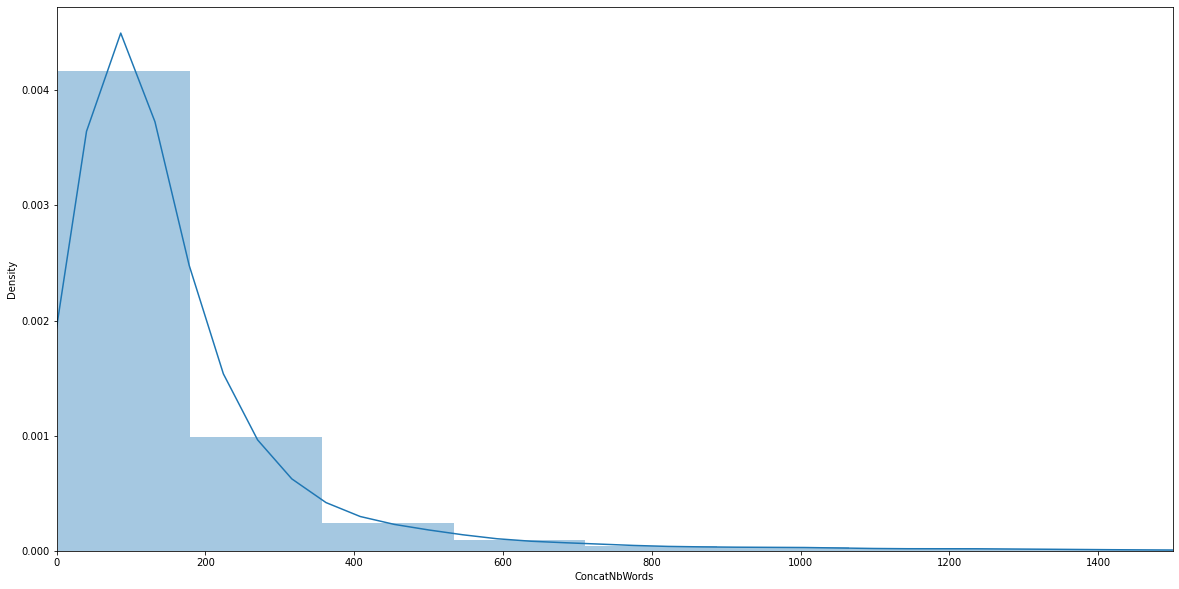

In [27]:

plt.figure(figsize=(20,10))
sns.distplot(data_frame['ConcatNbWords'])
plt.xlim(0,1500)

As most of the text having words of 600 so for will keep 600 as maximum length of padding sequence

In [28]:
import pickle
with open("/content/gdrive/My Drive/glove_vectors","rb") as glov_file:
  glove_model = pickle.load(glov_file)
  glove_words =  set(glove_model.keys())

In [29]:
data_frame.shape

(18828, 9)

In [30]:
data_frame["class"].unique()

array(['comp.sys.ibm.pc.hardware', 'talk.politics.misc',
       'rec.sport.baseball', 'rec.autos', 'misc.forsale', 'comp.graphics',
       'comp.sys.mac.hardware', 'rec.sport.hockey',
       'comp.os.ms-windows.misc', 'sci.space', 'talk.religion.misc',
       'sci.electronics', 'talk.politics.guns', 'comp.windows.x',
       'sci.med', 'talk.politics.mideast', 'sci.crypt', 'rec.motorcycles',
       'alt.atheism', 'soc.religion.christian'], dtype=object)

In [31]:
class_rename_index= dict([(index,class_val) for class_val,index in enumerate(data_frame['class'].unique())])
#data_rename['class_rename'] = data_frame['class'].map(lambda val: class_rename_index[val])

In [32]:
class_rename_val = []
for value in (data_frame["class"]):
  class_rename_val.append(class_rename_index[value])


In [33]:
data_frame["class_rename"] = class_rename_val

In [34]:
data_frame.columns

Index(['Unnamed: 0', 'PreprocessedText', 'class', 'Subject', 'Email',
       'DocName', 'Text', 'ConcatText', 'ConcatNbWords', 'class_rename'],
      dtype='object')

In [35]:

X_train, X_test, Y_train, Y_test = train_test_split(
      data_frame["ConcatText"],data_frame['class_rename'] , test_size=0.25, stratify=data_frame['class_rename'])


In [36]:

tokenize_word =tf.keras.preprocessing.text.Tokenizer(
    num_words=9000, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True,
    split=' ', char_level=False
)

In [37]:
tokenize_word.fit_on_texts(X_train)
#X_train[0]

In [38]:
length_of_vocab = len(tokenize_word.index_word) +1
print(length_of_vocab)

92294


In [39]:
X_train_encoded_sequence = tokenize_word.texts_to_sequences(X_train) 
X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(X_train_encoded_sequence,maxlen=600,padding='post')
X_test_encoded_sequence = tokenize_word.texts_to_sequences(X_test) 
X_test_pad = tf.keras.preprocessing.sequence.pad_sequences(X_test_encoded_sequence,maxlen=600,padding='post')


In [40]:
Y_train_encode = tf.keras.utils.to_categorical(Y_train, 20)
Y_test_encode = tf.keras.utils.to_categorical(Y_test, 20)

Embedding word matrix

In [41]:
embedding_matrix = np.zeros((length_of_vocab, 300))
for word, i in tokenize_word.word_index.items():
	embedding_vector = glove_model.get(word)
	if embedding_vector is not None:
		embedding_matrix[i] = embedding_vector

Creating Custom Metrics

In [42]:
class CustomMetrics(tf.keras.callbacks.Callback):
    
    def __init__(self, X_val,Y_val): 
        super(CustomMetrics, self).__init__()
        self.X = X_val
        self.Y = Y_val
        #print(self.X,self.Y)
    
    def on_train_begin(self, logs={}):
        ## on begin of training, we are creating a instance varible called history
        ## it is a dict with keys [loss, acc, val_loss, val_acc]
        self.history={'loss': [],'acc': [],'val_loss': [],'val_acc': []}
        self.cust_accuracy = []
        self.f1_score = []
        
    def on_epoch_end(self, epoch, logs={}):
        prob_score_of_y = self.model.predict(self.X)
        original_y = np.array(self.Y)
        calculated_y = []
        actual_y = []
        for value1,value2 in zip(original_y,prob_score_of_y):
            calculated_y.append(np.argmax(value2))
            actual_y.append(np.argmax(value1))
        micro_f1_score =f1_score(actual_y, calculated_y, average='micro') 
        self.f1_score.append(micro_f1_score)
        print("MICRO F1 SCORE",micro_f1_score)

                
                

creating object of custom metrics for model 1

In [43]:
custom_metrices = CustomMetrics(X_test_pad,Y_test_encode)

file path for model 1 

In [44]:
L=1 
filepath="best_model_{L}.h5".format(L=L)




Checkpoint for model 1

In [45]:
checkpoint = ModelCheckpoint(filepath=filepath, monitor='val_acc',  verbose=1, save_best_only=True, mode='max')




Early Stopping for model 1

In [46]:
earlystop = EarlyStopping(monitor='val_acc', min_delta=0, patience=3, verbose=1)




tensorboard for model 1

In [47]:
log_dir= "logs"+datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,histogram_freq=1, write_graph=True,write_grads=True)




Call Back List

In [48]:
callback_list = [custom_metrices,checkpoint,earlystop,tensorboard_callback]

### Model-1: Using 1D convolutions with word embeddings

In [3]:
tf.keras.backend.clear_session()

Input_layer_model1 = Input(shape=(600,))
embedding_model1   = Embedding(length_of_vocab, 300, weights=[embedding_matrix], input_length=600, trainable=False)(Input_layer_model1) 

layer1_1_model1     = Conv1D(32, 4, activation='tanh')(embedding_model1) 
layer1_2_model1     = Conv1D(32, 5, activation='tanh')(embedding_model1)
layer1_3_model1     = Conv1D(32, 6, activation='tanh')(embedding_model1)
concat1_model1     = Concatenate(axis=1)([layer1_1_model1, layer1_2_model1, layer1_3_model1])
maxpool1_model1    = MaxPooling1D(pool_size=2, strides=1, padding="valid")(concat1_model1)

layer2_1_model1     = Conv1D(16, 5, activation='tanh')(maxpool1_model1)
layer2_2_model1     = Conv1D(16, 6, activation='tanh')(maxpool1_model1)
layer2_3_model1     = Conv1D(16, 7, activation='tanh')(maxpool1_model1)
concat2_model1     = Concatenate(axis=1)([layer2_1_model1, layer2_2_model1, layer2_3_model1])
maxpool2_model1    = MaxPooling1D(pool_size=2, strides=1, padding="valid")(concat2_model1)

layer3_1_model1     = Conv1D(16, 3, activation='tanh')(maxpool2_model1)
flat_model1      = Flatten()(layer3_1_model1)
drop_model1      = Dropout(.5)(flat_model1)
dense_model1     = Dense(48, activation='tanh',kernel_initializer=tf.keras.initializers.he_uniform(seed=50),
                      kernel_regularizer=tf.keras.regularizers.l2(0.3))(drop_model1)

Output_for_model1      = Dense(20,activation='softmax',
               kernel_initializer=tf.keras.initializers.he_uniform(seed=60))(dense_model1)


NameError: name 'length_of_vocab' is not defined

Creating Model 1

In [50]:
Model1        = Model(inputs=Input_layer_model1,outputs=Output_for_model1)

optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)

Model1.compile(optimizer=optimizer, loss='categorical_crossentropy',metrics=['acc'])

Model1.fit(X_train_pad,Y_train_encode,epochs=50, validation_data=(X_test_pad,Y_test_encode), batch_size=16, callbacks=callback_list)

Epoch 1/50
  1/883 [..............................] - ETA: 0s - loss: 32.0280 - acc: 0.0000e+00WARNING:tensorflow:From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/summary_ops_v2.py:1277: stop (from tensorflow.python.eager.profiler) is deprecated and will be removed after 2020-07-01.
Instructions for updating:
use `tf.profiler.experimental.stop` instead.
883/883 [==============================] - ETA: 0s - loss: 11.4716 - acc: 0.2773MICRO F1 SCORE 0.4529424261737837

Epoch 00001: val_acc improved from -inf to 0.45294, saving model to best_model_1.h5
883/883 [==============================] - 16s 19ms/step - loss: 11.4716 - acc: 0.2773 - val_loss: 3.8217 - val_acc: 0.4529
Epoch 2/50
879/883 [============================>.] - ETA: 0s - loss: 2.6628 - acc: 0.5289MICRO F1 SCORE 0.5196515827490971

Epoch 00002: val_acc improved from 0.45294 to 0.51965, saving model to best_model_1.h5
883/883 [==============================] - 16s 18ms/step - loss: 2.6606 - acc: 0.5288 - val_

Using relu insted tanh the model get overfits

With regularizer and less no of layers in the dense layer, the gap between training and validation accuracy has been decreased


Comparitively word embedding perform better than character embedding

In [51]:
shutil.move("logs20201017-201018","/content/gdrive/My Drive")

'/content/gdrive/My Drive/logs20201017-201018'

<pre>
<b>Encoding of the Text </b> --> For a given text data create a Matrix with Embedding layer as shown Below. 
In the example we have considered d = 5, but in this assignment we will get d = dimension of Word vectors we are using.
 i.e if we have maximum of 350 words in a sentence and embedding of 300 dim word vector, 
 we result in 350*300 dimensional matrix for each sentance as output after embedding layer
<img src='https://i.imgur.com/kiVQuk1.png'>
Ref: https://i.imgur.com/kiVQuk1.png

<b>Reference:</b>
<a href='https://stackoverflow.com/a/43399308/4084039'>https://stackoverflow.com/a/43399308/4084039</a>
<a href='https://missinglink.ai/guides/keras/keras-conv1d-working-1d-convolutional-neural-networks-keras/'>https://missinglink.ai/guides/keras/keras-conv1d-working-1d-convolutional-neural-networks-keras/</a>

<b><a href='https://stats.stackexchange.com/questions/270546/how-does-keras-embedding-layer-work'>How EMBEDDING LAYER WORKS </a></b>

</pre>

### Go through this blog, if you have any doubt on using predefined Embedding values in Embedding layer - https://machinelearningmastery.com/use-word-embedding-layers-deep-learning-keras/

<img src='https://i.imgur.com/fv1GvFJ.png'>
ref: 'https://i.imgur.com/fv1GvFJ.png'

<pre>
1. all are Conv1D layers with any number of filter and filter sizes, there is no restriction on this.

2. use concatenate layer is to concatenate all the filters/channels. 

3. You can use any pool size and stride for maxpooling layer.

4. Don't use more than 16 filters in one Conv layer becuase it will increase the no of params. 
( Only recommendation if you have less computing power )

5. You can use any number of layers after the Flatten Layer.
</pre>

### Model-2 : Using 1D convolutions with character embedding

<pre>
<pre><img src="https://i.ytimg.com/vi/CNY8VjJt-iQ/maxresdefault.jpg" width="70%">
Here are the some papers based on Char-CNN
 1. Xiang Zhang, Junbo Zhao, Yann LeCun. <a href="http://arxiv.org/abs/1509.01626">Character-level Convolutional Networks for Text Classification</a>.NIPS 2015
 2. Yoon Kim, Yacine Jernite, David Sontag, Alexander M. Rush. <a href="https://arxiv.org/abs/1508.06615">Character-Aware Neural Language Models</a>. AAAI 2016
 3. Shaojie Bai, J. Zico Kolter, Vladlen Koltun. <a href="https://arxiv.org/pdf/1803.01271.pdf">An Empirical Evaluation of Generic Convolutional and Recurrent Networks for Sequence Modeling</a>
 4. Use the pratrained char embeddings <a href='https://github.com/minimaxir/char-embeddings/blob/master/glove.840B.300d-char.txt'>https://github.com/minimaxir/char-embeddings/blob/master/glove.840B.300d-char.txt</a>
</pre>

Cleaning concat text replacing " ____" and other special character from concat text

In [52]:
from tqdm import tqdm
clean_concat = []
for value in tqdm(data_frame["ConcatText"]):
    value=value.replace("____","").replace("___","").replace(".","").replace("/","").replace("-","").replace("[","").replace("]","").replace("(","").replace(")","")
    value =value.replace(",","").replace(":","").replace(";","").replace("+","").replace("=","").replace("%","").replace("^","").replace("*","").replace("&","")
    clean_concat.append(value) 
      


100%|██████████| 18828/18828 [00:00<00:00, 53056.71it/s]


In [53]:
data_frame["clean_concat"] =clean_concat

In [54]:
data_frame["characlength"] = data_frame['clean_concat'].apply(len)

In [55]:
data_frame.shape

(18828, 12)

In [56]:
data_frame["characlength"].describe()

count    18828.000000
mean      1121.366582
std       2205.005238
min         17.000000
25%        393.000000
50%        660.000000
75%       1138.000000
max      56174.000000
Name: characlength, dtype: float64

Functionality to choose maximum character length

In [57]:
greater_than_1000_less_than_1500 = []
greater_than_1500_less_than_2000 = []
greater_than_2000_less_than_2500 = []
greater_than_2500= []
less_than_1000 = []
for value in data_frame["characlength"]:
    if (value > 1000 and value <1500) :
        greater_than_1000_less_than_1500.append(value)
    elif (value > 1500 and value <2000):
        greater_than_1500_less_than_2000.append(value)
    elif (value > 2000 and value <2500):
        greater_than_2000_less_than_2500.append(value)
    elif (value < 1000):
        less_than_1000.append(value)
    elif (value > 2500):
        greater_than_2500.append(value)
print((len(greater_than_1000_less_than_1500)/len(data_frame["characlength"]))*100,"greater than 1000 less than 1500")
print((len(greater_than_1500_less_than_2000)/len(data_frame["characlength"]))*100,"greater than 1500 less than 2000")
print((len(greater_than_2000_less_than_2500)/len(data_frame["characlength"]))*100,"greater than 2000 less than 2500")
print((len(less_than_1000)/len(data_frame["characlength"]))*100,"less than 1000")
print((len(greater_than_2500)/len(data_frame["characlength"]))*100,"greater than 2500")            

13.671128107074571 greater than 1000 less than 1500
6.102613129381772 greater than 1500 less than 2000
3.1336307626938598 greater than 2000 less than 2500
69.87465476949225 less than 1000
7.143615891225834 greater than 2500


As almost 90% of the senetnce having a character leength of 2000 or less than 2000 so max length of charcater embedding will be 2000

Mapping character to interger

In [58]:
total_char = 'abcdefghijklmnopqrstuvwxyz_ ' 
char_dict = dict((char, index) for index, char in enumerate(total_char)) 
length_char_vocab = len(char_dict) + 1

Instializing Countvectorizer which will act in similar way as our glove vector for word embedding

In [59]:
vectorizer = CountVectorizer(analyzer= 'char') #
vectorizer.fit([total_char])
embedding_matrix_for_char = np.zeros((length_char_vocab, 28))


In [60]:
for character,index in char_dict.items():
  embedding_matrix_for_char[index] = vectorizer.transform([character]).toarray()[0]

Character embedding functionality

In [26]:
def char_embedding_function(X):
  embedded_char = np.zeros((len(X),2000))
  for index, word in enumerate(X):
    if len(word) < 2000:
      for index1,character in enumerate(word):
        if char_dict.get(character):
          embedded_char[index,index1] = char_dict[character]
        else:
          embedded_char[index,index1] = 27
    else:
        for index2,char1 in enumerate(word[:2000]):  
          if char_dict.get(char1):
            embedded_char[index,index2] = char_dict[char1]
          else:
            embedded_char[index,index2] = 27     
  return embedded_char   

Checkpoint and file path for Model 2

In [69]:
L=2
filepath="best_model_{L}.h5".format(L=L)
checkpoint = ModelCheckpoint(filepath=filepath, monitor='val_acc',  verbose=1, save_best_only=True, mode='max')

Early stopping

In [70]:
earlystop = EarlyStopping(monitor='val_acc', min_delta=0, patience=3, verbose=1)

tensorbord logs for model 2

In [71]:
log_dir= "logs2"+datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,histogram_freq=1, write_graph=True,write_grads=True)




call back list for model 2

In [72]:
callback_list = [custom_metrices,checkpoint,earlystop,tensorboard_callback]

Model 2 layer and architecture

In [73]:


Input_layer_model2 = Input(shape=(2000,)) 
embedding_layer_model2   = Embedding(length_char_vocab, 28, weights=[embedding_matrix_for_char],input_length=2000,trainable= True)(Input_layer_model2) 

layer1_1_model2     = Conv1D(64, 64, activation='tanh')(embedding_layer_model2)
layer1_2_model2     = Conv1D(64, 48, activation='tanh')(layer1_1_model2)
maxpool1_model2    = MaxPooling1D(pool_size=2, strides=2, padding="valid")(layer1_2_model2)

layer2_1_model2     = Conv1D(48, 32, activation='tanh')(maxpool1_model2)
layer2_2_model2     = Conv1D(48, 24, activation='tanh')(layer2_1_model2)
maxpoo2_model2    = MaxPooling1D(pool_size=2, strides=2, padding="valid")(layer2_2_model2)

flat_model2      = Flatten()(maxpoo2_model2)
drop1_model2      = Dropout(.5)(flat_model2 )
dense1_model2     = Dense(256, activation='tanh')(drop1_model2)

drop2_model2      = Dropout(.3)(dense1_model2)
dense2_model2     = Dense(128, activation='tanh')(drop2_model2)

output_for_model2      = Dense(20,activation='softmax')(dense2_model2)
Model2        = Model(inputs=Input_layer_model2,outputs=output_for_model2)

optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)



Creating Model 2

In [74]:
Model2.compile(optimizer=optimizer, loss='categorical_crossentropy',metrics=['acc'])
custom_metrices = CustomMetrics(char_embedding_function(X_test),Y_test_encode)



Model2.fit(char_embedding_function(X_train),Y_train_encode,epochs=10, validation_data=(char_embedding_function(X_test),Y_test_encode), batch_size=16, callbacks=callback_list)

Epoch 1/10
882/883 [============================>.] - ETA: 0s - loss: 2.9719 - acc: 0.0748MICRO F1 SCORE 0.09029105587422986

Epoch 00001: val_acc improved from -inf to 0.09029, saving model to best_model_2.h5
883/883 [==============================] - 21s 24ms/step - loss: 2.9720 - acc: 0.0747 - val_loss: 2.9160 - val_acc: 0.0903
Epoch 2/10
882/883 [============================>.] - ETA: 0s - loss: 2.8787 - acc: 0.1074MICRO F1 SCORE 0.10006373486297004

Epoch 00002: val_acc improved from 0.09029 to 0.10006, saving model to best_model_2.h5
883/883 [==============================] - 21s 24ms/step - loss: 2.8786 - acc: 0.1076 - val_loss: 2.8819 - val_acc: 0.1001
Epoch 3/10
883/883 [==============================] - ETA: 0s - loss: 2.7737 - acc: 0.1476MICRO F1 SCORE 0.12258338644571914

Epoch 00003: val_acc improved from 0.10006 to 0.12258, saving model to best_model_2.h5
883/883 [==============================] - 21s 24ms/step - loss: 2.7737 - acc: 0.1476 - val_loss: 2.8062 - val_acc: 0.

# Model 2 obeservation


Addition of regularizer layer, train and validation accuracy gap decereased but it also keep train accuracy at a lower side.

If we use relu insted of tanh the model get overfits quite easily

Overall word embedding perform better than character embedding

In [75]:
shutil.move("logs220201017-202934","/content/gdrive/My Drive")

'/content/gdrive/My Drive/logs220201017-202934'

<img src='https://i.imgur.com/EuuoJtr.png'>

In [29]:
%load_ext tensorboard



The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [32]:
!kill 1372

'kill' is not recognized as an internal or external command,
operable program or batch file.


In [33]:
%tensorboard --logdir "./logs20201017-201018/"

Reusing TensorBoard on port 6006 (pid 5792), started 0:00:56 ago. (Use '!kill 5792' to kill it.)